In [1]:
if (!require("pacman")) install.packages("pacman")

pacman::p_load(
  tidyverse,
  haven,
  knitr, scales
)

Cargando paquete requerido: pacman



In [2]:
# =========================
# 1. CARGAR rates.dta
# =========================
df <- read_dta("rates.dta")

df <- df %>%
  mutate(
    es_mexico = ifelse(Mexico == 1, 1, 0),
    conc = ferrocarril
  )

In [3]:
# =========================
# 2. CREAR mix_productos
# =========================
mix_productos <- tribble(
  ~conc, ~anio, ~sh_agricola, ~sh_animales, ~sh_minerales, ~sh_petroleo, ~sh_inorganicos, ~sh_industriales, ~sh_forestales,

  # FXE
  "FXE", 2005, 0.259834, 0.005156, 0.220002, 0.102717, 0.014942, 0.392803, 0.004546,
  "FXE", 2006, 0.352767, 0.009201, 0.172253, 0.055356, 0.015642, 0.390506, 0.004275,
  "FXE", 2007, 0.363632, 0.010080, 0.168557, 0.048541, 0.015526, 0.388981, 0.004683,
  "FXE", 2008, 0.378274, 0.009877, 0.161928, 0.046812, 0.012694, 0.388870, 0.001544,
  "FXE", 2009, 0.366223, 0.011741, 0.162311, 0.065996, 0.013146, 0.379067, 0.001516,
  "FXE", 2010, 0.364380, 0.012172, 0.162485, 0.053663, 0.019055, 0.386751, 0.001493,
  "FXE", 2011, 0.344707, 0.011538, 0.175031, 0.055195, 0.019225, 0.392488, 0.001816,
  "FXE", 2012, 0.297928, 0.012767, 0.176047, 0.065276, 0.015795, 0.428228, 0.003958,
  "FXE", 2013, 0.313519, 0.011867, 0.177052, 0.055696, 0.012028, 0.433423, 0.004415,
  "FXE", 2014, 0.311461, 0.010985, 0.176032, 0.059696, 0.011568, 0.435831, 0.004427,
  "FXE", 2015, 0.335140, 0.011007, 0.160514, 0.059384, 0.012454, 0.427620, 0.004209,
  "FXE", 2016, 0.343099, 0.009242, 0.143896, 0.049442, 0.011591, 0.440403, 0.002327,
  "FXE", 2017, 0.370971, 0.009244, 0.169592, 0.045084, 0.012466, 0.408531, 0.004209,
  "FXE", 2018, 0.385294, 0.009243, 0.180365, 0.034374, 0.012337, 0.391946, 0.002559,
  "FXE", 2019, 0.400532, 0.007193, 0.157249, 0.035879, 0.027800, 0.375354, 0.001650,
  "FXE", 2020, 0.387879, 0.007700, 0.145502, 0.062838, 0.029190, 0.373316, 0.002234,
  "FXE", 2021, 0.402457, 0.007612, 0.150774, 0.050850, 0.027599, 0.375513, 0.002317,

  # KCSM
  "KCSM", 2005, 0.179800, 0.008465, 0.073140, 0.018252, 0.029985, 0.685233, 0.005125,
  "KCSM", 2006, 0.228966, 0.006959, 0.063879, 0.026270, 0.024053, 0.628934, 0.020939,
  "KCSM", 2007, 0.241416, 0.006259, 0.070578, 0.026382, 0.023714, 0.589076, 0.017462,
  "KCSM", 2008, 0.265278, 0.005974, 0.072400, 0.032968, 0.023428, 0.549009, 0.018483,
  "KCSM", 2009, 0.259523, 0.006025, 0.055729, 0.042278, 0.021774, 0.560471, 0.015381,
  "KCSM", 2010, 0.213891, 0.004753, 0.073501, 0.037112, 0.025584, 0.612076, 0.018890,
  "KCSM", 2011, 0.223432, 0.005241, 0.068513, 0.041359, 0.029291, 0.622029, 0.016818,
  "KCSM", 2012, 0.213827, 0.004943, 0.063826, 0.038436, 0.023839, 0.650340, 0.012866,
  "KCSM", 2013, 0.185284, 0.004266, 0.062571, 0.041884, 0.023003, 0.678647, 0.011113,
  "KCSM", 2014, 0.214218, 0.003960, 0.054038, 0.049003, 0.019992, 0.654017, 0.019929,
  "KCSM", 2015, 0.220220, 0.003341, 0.054671, 0.082433, 0.020845, 0.625441, 0.019920,
  "KCSM", 2016, 0.240366, 0.003410, 0.053931, 0.077461, 0.021283, 0.613182, 0.019921,
  "KCSM", 2017, 0.216371, 0.003408, 0.056649, 0.104668, 0.020813, 0.609524, 0.019920,
  "KCSM", 2018, 0.208810, 0.003254, 0.059025, 0.137159, 0.017803, 0.566238, 0.019920,
  "KCSM", 2019, 0.195638, 0.003408, 0.058779, 0.168301, 0.021549, 0.550394, 0.019920,
  "KCSM", 2020, 0.198572, 0.002838, 0.054481, 0.191223, 0.019699, 0.516909, 0.022260,
  "KCSM", 2021, 0.213102, 0.002566, 0.056040, 0.209015, 0.019697, 0.475045, 0.025431
)

# Verificación equivalente a Stata
mix_productos <- mix_productos %>%
  mutate(
    suma_check = sh_agricola + sh_animales + sh_minerales +
      sh_petroleo + sh_inorganicos + sh_industriales + sh_forestales
  )

print(mean(mix_productos$suma_check, na.rm = TRUE))

[1] 1.004322


In [5]:
# =========================
# 3. INDICADORES DE mix_productos
# =========================
agr <- mix_productos %>%
  filter(conc %in% c("FXE", "KCSM"),
         anio >= 2017, anio <= 2021) %>%
  group_by(conc) %>%
  summarise(
    agricola = mean(sh_agricola, na.rm = TRUE) * 100,
    .groups = "drop"
  )

pet <- mix_productos %>%
  filter(conc %in% c("FXE", "KCSM"),
         anio >= 2017, anio <= 2021) %>%
  group_by(conc) %>%
  summarise(
    petroleo = mean(sh_petroleo, na.rm = TRUE) * 100,
    .groups = "drop"
  )


manuf <- df %>%
  filter(ferrocarril %in% c("FXE", "KCSM"),
         per == 2021) %>%
  group_by(ferrocarril) %>%
  summarise(
    manufactura = mean(manufacturas, na.rm = TRUE) * 100,
    .groups = "drop"
  ) %>%
  rename(conc = ferrocarril)

# =========================
# 4. HHI
# =========================
hhi <- tibble(
  conc = c("FXE", "KCSM"),
  hhi_2005 = c(0.281030, 0.508552),
  hhi_2021 = c(0.324255, 0.322876)
)

# =========================
# 5. CREAR rentabilidad
# =========================
rentabilidad <- tribble(
  ~conc, ~anio, ~OR, ~HHI, ~ebit_ta, ~reinversion, ~densidad,

  # FXE
  "FXE", 2005, NA, 0.281030, NA, NA, 77.289,
  "FXE", 2006, NA, 0.310023, NA, NA, 90.184,
  "FXE", 2007, NA, 0.314666, NA, NA, NA,
  "FXE", 2008, NA, 0.322984, NA, NA, NA,
  "FXE", 2009, NA, 0.308825, NA, NA, NA,
  "FXE", 2010, NA, 0.312144, NA, NA, NA,
  "FXE", 2011, NA, 0.307058, NA, NA, NA,
  "FXE", 2012, 0.782507, 0.307822, 0.168725, 0.152077, NA,
  "FXE", 2013, 0.795814, 0.317243, 0.150941, 0.183522, NA,
  "FXE", 2014, 0.787257, 0.317922, 0.155430, 0.152077, 121.072,
  "FXE", 2015, 0.765147, 0.325132, 0.187145, 0.183522, 116.827,
  "FXE", 2016, 0.752145, 0.336195, 0.220043, 0.138835, 115.619,
  "FXE", 2017, 0.790673, 0.332328, 0.167873, 0.141509, 117.792,
  "FXE", 2018, 0.773824, 0.330265, 0.189754, 0.162299, 119.347,
  "FXE", 2019, 0.755585, 0.323431, 0.198981, 0.145613, 115.257,
  "FXE", 2020, 0.766219, 0.313406, 0.185152, 0.117175, 109.925,
  "FXE", 2021, 0.741417, 0.324255, 0.212615, 0.133241, 121.608,
  "FXE", 2022, 0.729698, NA, 0.218993, 0.131019, NA,
  "FXE", 2023, 0.719879, NA, 0.231340, 0.120688, NA,

  # KCSM
  "KCSM", 2005, NA, 0.508552, NA, NA, 147.697,
  "KCSM", 2006, NA, 0.453819, NA, NA, 151.962,
  "KCSM", 2007, NA, 0.419296, NA, NA, NA,
  "KCSM", 2008, NA, 0.384543, NA, NA, NA,
  "KCSM", 2009, NA, 0.394161, NA, NA, NA,
  "KCSM", 2010, NA, 0.437532, NA, NA, NA,
  "KCSM", 2011, NA, 0.443211, NA, NA, NA,
  "KCSM", 2012, 0.595121, 0.474514, 0.194453, 0.183575, NA,
  "KCSM", 2013, 0.643538, 0.500078, 0.155972, 0.277119, NA,
  "KCSM", 2014, 0.641547, 0.479889, 0.156439, 0.163781, 227.912,
  "KCSM", 2015, 0.632275, 0.448408, 0.177212, 0.277119, 200.161,
  "KCSM", 2016, 0.597795, 0.440820, 0.193032, 0.163781, 204.456,
  "KCSM", 2017, 0.588749, 0.430051, 0.201710, 0.148428, 207.501,
  "KCSM", 2018, 0.617164, 0.391828, 0.200365, 0.207710, 212.864,
  "KCSM", 2019, 0.565308, 0.374311, 0.218153, 0.178872, 199.631,
  "KCSM", 2020, 0.568986, 0.348599, 0.201908, 0.135490, 182.583,
  "KCSM", 2021, 0.570899, 0.322876, 0.198549, 0.135298, 177.783,
  "KCSM", 2022, 0.557858, NA, 0.210132, 0.095593, NA,
  "KCSM", 2023, 0.642311, NA, 0.180011, 0.099000, NA
)

# =========================
# 6. EBIT Y REINVERSIÓN
# =========================
ebit <- rentabilidad %>%
  filter(conc %in% c("FXE", "KCSM"),
         anio >= 2017, anio <= 2021) %>%
  group_by(conc) %>%
  summarise(
    ebit = mean(ebit_ta, na.rm = TRUE) * 100,
    .groups = "drop"
  )

reinv <- rentabilidad %>%
  filter(conc %in% c("FXE", "KCSM"),
         anio >= 2015, anio <= 2021) %>%
  group_by(conc) %>%
  summarise(
    reinv = mean(reinversion, na.rm = TRUE) * 100,
    .groups = "drop"
  )

In [ ]:
# =========================
# 7. UNIR TABLAS
# =========================
tabla <- agr %>%
  left_join(pet, by = "conc") %>%
  left_join(manuf, by = "conc") %>%
  left_join(hhi, by = "conc") %>%
  left_join(ebit, by = "conc") %>%
  left_join(reinv, by = "conc")

In [ ]:
# =========================
# 8. TABLA FINAL
# =========================
tabla_final <- tabla %>%
  select(
    conc,
    agricola,
    petroleo,
    manufactura,
    hhi_2005,
    hhi_2021,
    ebit,
    reinv
  ) %>%
  rename(
    "Participación agrícola promedio 2017–2021" = agricola,
    "Participación petróleo promedio 2017–2021" = petroleo,
    "Participación manufactura (2021)" = manufactura,
    "HHI diversificación 2005" = hhi_2005,
    "HHI diversificación 2021" = hhi_2021,
    "EBIT/Activos promedio 2017–2021" = ebit,
    "Reinversión media 2015–2021 (% ingresos)" = reinv
  )

tabla_final

# Imprimir con formato
kable(tabla_final, digits = 3)

conc,Participación agrícola promedio 2017–2021,Participación petróleo promedio 2017–2021,Participación manufactura (2021),HHI diversificación 2005,HHI diversificación 2021,EBIT/Activos promedio 2017–2021,Reinversión media 2015–2021 (% ingresos)
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FXE,38.94266,4.58050,43.60677,0.281030,0.324255,19.0875,14.60277
KCSM,20.64986,16.20732,48.59691,0.508552,0.322876,20.4137,17.80997




|conc | Participación agrícola promedio 2017–2021| Participación petróleo promedio 2017–2021| Participación manufactura (2021)| HHI diversificación 2005| HHI diversificación 2021| EBIT/Activos promedio 2017–2021| Reinversión media 2015–2021 (% ingresos)|
|:----|-----------------------------------------:|-----------------------------------------:|--------------------------------:|------------------------:|------------------------:|-------------------------------:|----------------------------------------:|
|FXE  |                                    38.943|                                     4.580|                           43.607|                    0.281|                    0.324|                          19.087|                                   14.603|
|KCSM |                                    20.650|                                    16.207|                           48.597|                    0.509|                    0.323|                          20.414|                     

#### Gráficas del documento

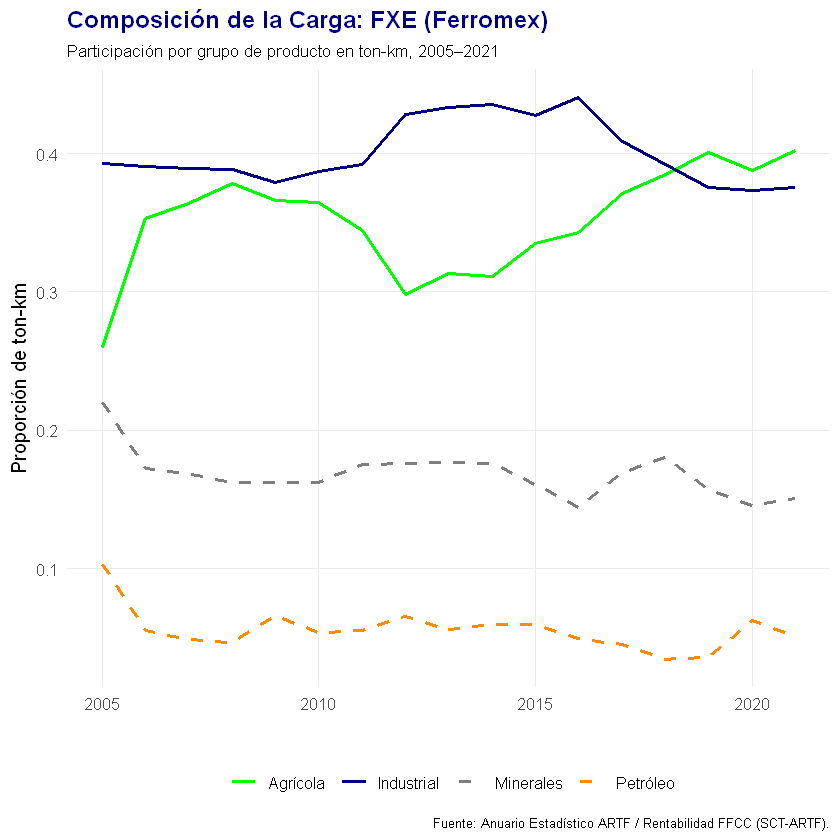

In [ ]:
# Filtrar FXE
df_plot <- mix_productos %>%
  filter(conc == "FXE") %>%
  select(anio, sh_agricola, sh_industriales, sh_petroleo, sh_minerales) %>%
  pivot_longer(-anio, names_to = "variable", values_to = "valor")

# Etiquetas
df_plot <- df_plot %>%
  mutate(variable = recode(variable,
    sh_agricola = "Agrícola",
    sh_industriales = "Industrial",
    sh_petroleo = "Petróleo",
    sh_minerales = "Minerales"
  ))

# Gráfica
ggplot(df_plot, aes(x = anio, y = valor, color = variable, linetype = variable)) +
  geom_line(size = 1) +

  # Colores equivalentes a Stata
  scale_color_manual(values = c(
    "Agrícola" = "green",
    "Industrial" = "navy",
    "Petróleo" = "darkorange",
    "Minerales" = "gray50"
  )) +

  # Tipos de línea
  scale_linetype_manual(values = c(
    "Agrícola" = "solid",
    "Industrial" = "solid",
    "Petróleo" = "dashed",
    "Minerales" = "dashed"
  )) +

  # Ejes
  scale_y_continuous(
    breaks = seq(0, 0.5, 0.1),
    labels = scales::number_format(accuracy = 0.1)
  ) +

  labs(
    title = "Composición de la Carga: FXE (Ferromex)",
    subtitle = "Participación por grupo de producto en ton-km, 2005–2021",
    x = "",
    y = "Proporción de ton-km",
    color = "",
    linetype = "",
    caption = "Fuente: Anuario Estadístico ARTF / Rentabilidad FFCC (SCT-ARTF)."
  ) +

  # Tema tipo Stata limpio
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "bottom",
    legend.direction = "horizontal",
    plot.title = element_text(color = "navy", face = "bold"),
    plot.subtitle = element_text(size = 10),
    plot.caption = element_text(size = 8),
    panel.grid.minor = element_blank()
  )

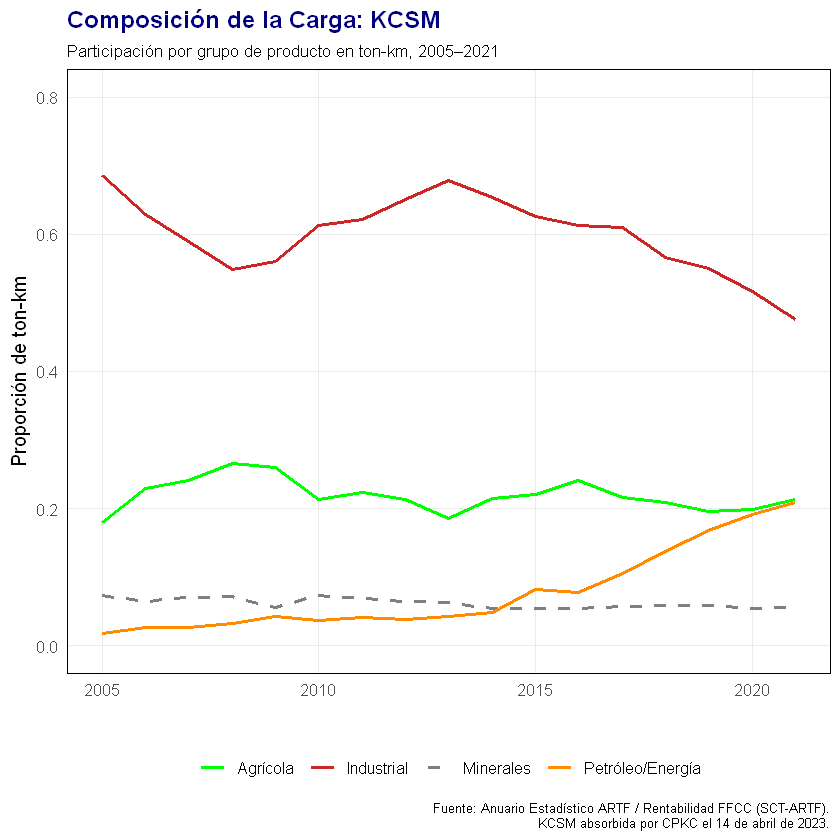

In [ ]:
# Filtrar KCSM
df_plot <- mix_productos %>%
  filter(conc == "KCSM") %>%
  select(anio, sh_agricola, sh_industriales, sh_petroleo, sh_minerales) %>%
  pivot_longer(-anio, names_to = "variable", values_to = "valor")

# Etiquetas
df_plot <- df_plot %>%
  mutate(variable = recode(variable,
    sh_agricola = "Agrícola",
    sh_industriales = "Industrial",
    sh_petroleo = "Petróleo/Energía",
    sh_minerales = "Minerales"
  ))

# Gráfica
ggplot(df_plot, aes(x = anio, y = valor, color = variable, linetype = variable)) +
  geom_line(size = 1) +

  # Colores estilo Stata
  scale_color_manual(values = c(
    "Agrícola" = "green",
    "Industrial" = "firebrick3",   # cranberry aprox
    "Petróleo/Energía" = "darkorange",
    "Minerales" = "gray50"
  )) +

  # Tipos de línea
  scale_linetype_manual(values = c(
    "Agrícola" = "solid",
    "Industrial" = "solid",
    "Petróleo/Energía" = "solid",
    "Minerales" = "dashed"
  )) +

  # Eje Y
  scale_y_continuous(
    limits = c(0, 0.8),
    breaks = seq(0, 0.8, 0.2),
    labels = scales::number_format(accuracy = 0.1)
  ) +

  labs(
    title = "Composición de la Carga: KCSM",
    subtitle = "Participación por grupo de producto en ton-km, 2005–2021",
    x = "",
    y = "Proporción de ton-km",
    color = "",
    linetype = "",
    caption = "Fuente: Anuario Estadístico ARTF / Rentabilidad FFCC (SCT-ARTF).\nKCSM absorbida por CPKC el 14 de abril de 2023."
  ) +

  # Tema tipo Stata limpio
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.box = "vertical",
    plot.title = element_text(color = "navy", face = "bold"),
    plot.subtitle = element_text(size = 10),
    plot.caption = element_text(size = 8),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "black", fill = NA)
  )

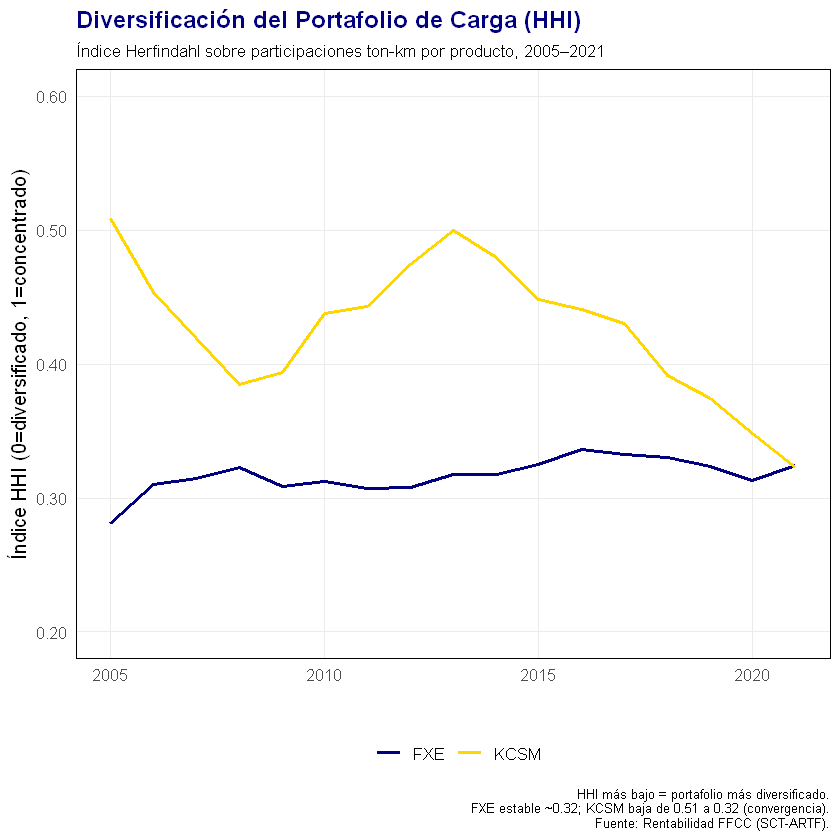

In [ ]:
# Filtrar datos
df_hhi <- rentabilidad %>%
  filter(conc %in% c("FXE", "KCSM"),
         anio >= 2005, anio <= 2021)

# Gráfica
ggplot(df_hhi, aes(x = anio, y = HHI, color = conc)) +
  geom_line(size = 1) +

  # Colores tipo Stata
  scale_color_manual(values = c(
    "FXE" = "navy",
    "KCSM" = "gold"
  )) +

  # Eje Y
  scale_y_continuous(
    limits = c(0.2, 0.6),
    breaks = seq(0.2, 0.6, 0.1),
    labels = number_format(accuracy = 0.01)
  ) +

  labs(
    title = "Diversificación del Portafolio de Carga (HHI)",
    subtitle = "Índice Herfindahl sobre participaciones ton-km por producto, 2005–2021",
    x = "",
    y = "Índice HHI (0=diversificado, 1=concentrado)",
    color = "",
    caption = paste(
      "HHI más bajo = portafolio más diversificado.",
      "FXE estable ~0.32; KCSM baja de 0.51 a 0.32 (convergencia).",
      "Fuente: Rentabilidad FFCC (SCT-ARTF).",
      sep = "\n"
    )
  ) +

  # Tema estilo Stata
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "bottom",
    legend.direction = "horizontal",
    plot.title = element_text(color = "navy", face = "bold"),
    plot.subtitle = element_text(size = 10),
    plot.caption = element_text(size = 8),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "black", fill = NA)
  )